**Step 1 — Notebook title and objective**

# Robustness and Validation

## Objective

This notebook evaluates whether the main machine-learning findings are robust
to reasonable changes in modelling assumptions and experimental configuration.

The robustness analysis focuses on:

1. Experimental integrity and data-leakage checks
2. Hyperparameter sensitivity and optimization
3. Random-seed stability
4. Target-threshold sensitivity
5. Optional feature-specification sensitivity

The existing temporal evaluation design is preserved:

- Training period: 2020–2024
- Final unseen test period: 2025
- Target: 5-trading-day stock movement
- Baseline threshold: ±1.5%

The primary models considered in robustness testing are:

- Logistic Regression
- Random Forest
- XGBoost

Robustness tests were selected according to the characteristics and methodological role of each model. Dummy was retained only as a trivial reference, while LSTM was treated as a supplementary deep-learning baseline and evaluated separately for reproducibility. The main robustness analysis therefore focused on the primary classical models, particularly the ensemble methods relevant to hyperparameter sensitivity.

**Step 2 — Imports**

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score
)

from xgboost import XGBClassifier

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

RANDOM_STATE = 42
TEST_YEAR = 2025
BASELINE_THRESHOLD = 0.015

print("Setup complete.")

Setup complete.


**Step 3 — Set reproducibility seeds**

In [2]:
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print("Random seed:", RANDOM_STATE)

Random seed: 42


**Step 4 — Load the same modelling dataset**

In [3]:
DATA_PATH = "/kaggle/input/notebooks/phyothaw/06-target-and-model-dataset-ipynb/model_ready_complete_case_2020_2025.csv"

data_df = pd.read_csv(DATA_PATH)

data_df["date"] = pd.to_datetime(data_df["date"])

print("Dataset shape:", data_df.shape)
display(data_df.head())

Dataset shape: (7370, 42)


,ticker,Open,High,Low,Close,Volume,Dividends,Stock Splits,SMA_50,SMA_200,EMA_50,EMA_200,RSI,MACD,MACD_Signal,MACD_Hist,BB_Upper,BB_Middle,BB_Lower,ATR,ADX,date,gdelt_company_tone,gdelt_tone_missing,gdelt_tone_lag_1,gdelt_tone_mean_3,gdelt_tone_mean_5,gdelt_tone_std_5,gdelt_tone_change_1d,gdelt_abnormal_tone_20,market_close,market_return,vix_close,vix_change,market_return_lag_1,vix_close_lag_1,vix_change_lag_1,daily_return_check,future_close_5d,forward_return_5d,movement_5d,target_5d
0,BRK-B,227.0500,228.4700,226.1300,228.4500,3286700,0.0000,0.0000,222.4416,210.6961,222.0380,212.6147,60.9110,1.6414,1.7916,-0.1502,228.5025,226.4395,224.3765,2.0712,24.1401,2020-01-13,0.1082,0,1.0689,0.3863,0.3871,0.4659,0.7778,0.4865,3288.1299,0.0070,12.3200,-0.0191,-0.0029,12.5600,0.0016,0.0081,228.6300,0.0008,Neutral,1
1,BRK-B,227.8500,228.3900,226.8800,227.1700,3355400,0.0000,0.0000,222.7334,210.8275,222.2392,212.7595,56.3503,1.5518,1.7436,-0.1919,228.5548,226.5295,224.5042,2.0354,23.7312,2020-01-14,0.6846,0,0.1082,0.4894,0.3000,0.4700,-0.9607,-0.5147,3283.1499,-0.0015,12.3900,0.0057,0.0070,12.3200,-0.0191,-0.0056,229.5400,0.0104,Neutral,1
2,BRK-B,226.8000,228.6400,226.7800,228.3500,2662500,0.0000,0.0000,222.9838,210.9442,222.4789,212.9146,59.3705,1.5580,1.7065,-0.1485,228.7774,226.6045,224.4316,2.0229,23.4895,2020-01-15,-0.9342,0,0.6846,0.6206,0.3903,0.4966,0.5764,0.1013,3289.2900,0.0019,12.4200,0.0024,-0.0015,12.3900,0.0057,0.0052,229.3800,0.0045,Neutral,1
3,BRK-B,229.3400,230.0300,228.5200,229.7300,3036400,0.0000,0.0000,223.2188,211.0735,222.7632,213.0819,62.6272,1.6552,1.6962,-0.0411,229.3005,226.7385,224.1765,1.9984,23.9712,2020-01-16,1.1183,0,-0.9342,-0.0471,0.2437,0.7555,-1.6188,-1.5248,3316.8101,0.0084,12.3200,-0.0081,0.0019,12.4200,0.0024,0.0060,226.8600,-0.0125,Neutral,1
4,BRK-B,230.1300,231.6100,229.5500,230.2000,6603800,0.0000,0.0000,223.4052,211.2061,223.0549,213.2523,63.6946,1.7500,1.7070,0.0430,229.8428,226.9980,224.1531,2.0028,25.0760,2020-01-17,1.3977,0,1.1183,0.2896,0.4092,0.8528,2.0525,0.6294,3329.6201,0.0039,12.1000,-0.0179,0.0084,12.3200,-0.0081,0.0020,222.4500,-0.0337,Down,0


**Step 5 — Add missing-value handling before feature selection**

In [4]:
# ==========================================================
# Handle Missing GDELT Tone
# Reproduce preprocessing used in Notebook 09
# ==========================================================

# Create an indicator showing whether GDELT tone was originally missing
data_df["gdelt_tone_missing"] = (
    data_df["gdelt_company_tone"]
    .isna()
    .astype(int)
)

# Replace missing tone with neutral value 0
data_df["gdelt_company_tone"] = (
    data_df["gdelt_company_tone"]
    .fillna(0)
)

# Check whether any missing values remain
missing = (
    data_df.isna()
    .sum()
    .sort_values(ascending=False)
)

print("Remaining missing values:")
display(
    missing[missing > 0].to_frame("Missing Count")
)

Remaining missing values:


,Missing Count


**Step 6 — Reproduce exact feature selection**

In [5]:
TARGET = "target_5d"

DROP_COLUMNS = [
    # Identifiers
    "ticker",
    "date",

    # Future information / leakage
    "future_close_5d",
    "forward_return_5d",

    # Target variables
    "movement_5d",
    "target_5d",

    # Low-information columns
    "Dividends",
    "Stock Splits",

    # Diagnostic column
    "daily_return_check"
]

FEATURE_COLUMNS = [
    column
    for column in data_df.columns
    if column not in DROP_COLUMNS
]

print("Number of predictor features:", len(FEATURE_COLUMNS))

print("\nPredictor features:")
for feature in FEATURE_COLUMNS:
    print("-", feature)

Number of predictor features: 33

Predictor features:
- Open
- High
- Low
- Close
- Volume
- SMA_50
- SMA_200
- EMA_50
- EMA_200
- RSI
- MACD
- MACD_Signal
- MACD_Hist
- BB_Upper
- BB_Middle
- BB_Lower
- ATR
- ADX
- gdelt_company_tone
- gdelt_tone_missing
- gdelt_tone_lag_1
- gdelt_tone_mean_3
- gdelt_tone_mean_5
- gdelt_tone_std_5
- gdelt_tone_change_1d
- gdelt_abnormal_tone_20
- market_close
- market_return
- vix_close
- vix_change
- market_return_lag_1
- vix_close_lag_1
- vix_change_lag_1


**Step 7 — Automatic future-information leakage check**

In [6]:
FORBIDDEN_FEATURES = [
    "future_close_5d",
    "forward_return_5d",
    "movement_5d",
    "target_5d"
]

leaked_features = [
    feature
    for feature in FORBIDDEN_FEATURES
    if feature in FEATURE_COLUMNS
]

if len(leaked_features) == 0:
    print("PASS: No explicit future/target variables are used as predictors.")
else:
    print("FAIL: Potential leakage detected:")
    print(leaked_features)

PASS: No explicit future/target variables are used as predictors.


**Step 8 — Reproduce the temporal train/test split**

In [7]:
train_df = (
    data_df[
        data_df["date"].dt.year < TEST_YEAR
    ]
    .sort_values(["ticker", "date"])
    .copy()
)

test_df = (
    data_df[
        data_df["date"].dt.year == TEST_YEAR
    ]
    .sort_values(["ticker", "date"])
    .copy()
)

X_train = train_df[FEATURE_COLUMNS]
y_train = train_df[TARGET]

X_test = test_df[FEATURE_COLUMNS]
y_test = test_df[TARGET]

print("=" * 60)
print("TEMPORAL SPLIT")
print("=" * 60)

print("Training samples:", len(train_df))
print("Testing samples :", len(test_df))

print("\nTraining period:")
print(train_df["date"].min(), "→", train_df["date"].max())

print("\nTesting period:")
print(test_df["date"].min(), "→", test_df["date"].max())

TEMPORAL SPLIT
Training samples: 6240
Testing samples : 1130

Training period:
2020-01-13 00:00:00 → 2024-12-31 00:00:00

Testing period:
2025-01-02 00:00:00 → 2025-12-22 00:00:00


**Step 9 — Automatically validate the temporal split**

In [8]:
last_train_date = train_df["date"].max()
first_test_date = test_df["date"].min()

print("Last training date :", last_train_date)
print("First testing date :", first_test_date)

assert last_train_date < first_test_date

print("\nPASS: Training data occur strictly before test data.")

Last training date : 2024-12-31 00:00:00
First testing date : 2025-01-02 00:00:00

PASS: Training data occur strictly before test data.


**Step 10 — Check class distributions**

In [9]:
def class_distribution(df, target="target_5d"):
    counts = df[target].value_counts().sort_index()
    proportions = df[target].value_counts(
        normalize=True
    ).sort_index()

    result = pd.DataFrame({
        "count": counts,
        "proportion": proportions
    })

    result.index = ["Down", "Neutral", "Up"]

    return result


print("TRAIN CLASS DISTRIBUTION")
display(class_distribution(train_df))

print("TEST CLASS DISTRIBUTION")
display(class_distribution(test_df))

TRAIN CLASS DISTRIBUTION


,count,proportion
Down,1763,0.2825
Neutral,1990,0.3189
Up,2487,0.3986


TEST CLASS DISTRIBUTION


,count,proportion
Down,282,0.2496
Neutral,424,0.3752
Up,424,0.3752


**Step 11 — Create one reusable evaluation function**

In [10]:
def evaluate_classifier(y_true, y_pred, y_prob=None):

    results = {
        "accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "balanced_accuracy": balanced_accuracy_score(
            y_true,
            y_pred
        ),

        "macro_f1": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        )
    }

    if y_prob is not None:
        try:
            results["roc_auc_ovr"] = roc_auc_score(
                y_true,
                y_prob,
                multi_class="ovr",
                labels=[0, 1, 2]
            )

        except ValueError:
            results["roc_auc_ovr"] = np.nan

    return results

**Step 12 — Build the baseline Random Forest**

In [11]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)

rf_results = evaluate_classifier(
    y_test,
    rf_pred,
    rf_prob
)

print("Random Forest baseline")
rf_results

Random Forest baseline


{'accuracy': 0.3530973451327434,
 'balanced_accuracy': np.float64(0.37068446407065436),
 'macro_f1': 0.35431335461550423,
 'roc_auc_ovr': np.float64(0.5664179565478845)}

**Step 13 — Baseline XGBoost**

In [12]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)

xgb_results = evaluate_classifier(
    y_test,
    xgb_pred,
    xgb_prob
)

print("XGBoost baseline")
xgb_results

XGBoost baseline


{'accuracy': 0.33716814159292036,
 'balanced_accuracy': np.float64(0.35257482492528663),
 'macro_f1': 0.3379061378971951,
 'roc_auc_ovr': np.float64(0.5306553466574727)}

**Step 14 — Baseline Logistic Regression**

In [13]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
lr_model = LogisticRegression(
    penalty="l2",
    class_weight="balanced",
    max_iter=2000,
    random_state=RANDOM_STATE
)

lr_model.fit(
    X_train_scaled,
    y_train
)

lr_pred = lr_model.predict(
    X_test_scaled
)

lr_prob = lr_model.predict_proba(
    X_test_scaled
)

lr_results = evaluate_classifier(
    y_test,
    lr_pred,
    lr_prob
)

print("Logistic Regression baseline")
lr_results

Logistic Regression baseline


{'accuracy': 0.38849557522123895,
 'balanced_accuracy': np.float64(0.3910466568535617),
 'macro_f1': 0.38213482082420197,
 'roc_auc_ovr': np.float64(0.5903083252684168)}

**Step 15 — Create the baseline comparison table**

In [14]:
baseline_results = pd.DataFrame([
    {
        "model": "Random Forest",
        **rf_results
    },
    {
        "model": "XGBoost",
        **xgb_results
    },
    {
        "model": "Logistic Regression",
        **lr_results
    }
])

baseline_results = baseline_results.sort_values(
    "balanced_accuracy",
    ascending=False
)

display(baseline_results)

,model,accuracy,balanced_accuracy,macro_f1,roc_auc_ovr
2,Logistic Regression,0.3885,0.3910,0.3821,0.5903
0,Random Forest,0.3531,0.3707,0.3543,0.5664
1,XGBoost,0.3372,0.3526,0.3379,0.5307


**Step 16 — Create your first validation summary**

In [15]:
validation_checks = pd.DataFrame([
    {
        "check": "Future variables excluded from predictors",
        "status": (
            "PASS"
            if len(leaked_features) == 0
            else "FAIL"
        )
    },

    {
        "check": "Training data occur before test data",
        "status": (
            "PASS"
            if last_train_date < first_test_date
            else "FAIL"
        )
    },

    {
        "check": "2025 reserved for final testing",
        "status": (
            "PASS"
            if test_df["date"].dt.year.eq(2025).all()
            else "FAIL"
        )
    },

    {
        "check": "Scaler fitted on training data only",
        "status": "PASS"
    }
])

display(validation_checks)

,check,status
0,Future variables excluded from predictors,PASS
1,Training data occur before test data,PASS
2,2025 reserved for final testing,PASS
3,Scaler fitted on training data only,PASS


# Hyperparameter Optimization
**Step 17 — Create tuning split**


In [16]:
# ==========================================================
# Time-aware tuning split
# 2020-2023 = training
# 2024      = validation
# 2025      = untouched final test
# ==========================================================

tuning_train_df = (
    data_df[data_df["date"].dt.year <= 2023]
    .sort_values(["ticker", "date"])
    .copy()
)

validation_df = (
    data_df[data_df["date"].dt.year == 2024]
    .sort_values(["ticker", "date"])
    .copy()
)

X_tune_train = tuning_train_df[FEATURE_COLUMNS]
y_tune_train = tuning_train_df[TARGET]

X_validation = validation_df[FEATURE_COLUMNS]
y_validation = validation_df[TARGET]

print("Tuning train:")
print(
    tuning_train_df["date"].min(),
    "→",
    tuning_train_df["date"].max()
)

print("\nValidation:")
print(
    validation_df["date"].min(),
    "→",
    validation_df["date"].max()
)

print("\nFinal test remains:")
print(
    test_df["date"].min(),
    "→",
    test_df["date"].max()
)

Tuning train:
2020-01-13 00:00:00 → 2023-12-29 00:00:00

Validation:
2024-01-02 00:00:00 → 2024-12-31 00:00:00

Final test remains:
2025-01-02 00:00:00 → 2025-12-22 00:00:00


**Step 18 — Decide tuning metric**
### Model-selection metric

Balanced Accuracy is used as the primary hyperparameter-selection
metric because the target classes are not necessarily equally represented.

The final 2025 test set is not used during hyperparameter selection.

In [17]:
TUNING_METRIC = "balanced_accuracy"

**Step 19 — Random Forest parameter grid**

In [18]:
rf_param_grid = {
    "n_estimators": [100, 300, 500],
    "max_depth": [5, 10, None],
    "min_samples_leaf": [1, 5, 10]
}

**Step 20 — Tune Random Forest**

In [19]:
from itertools import product

rf_tuning_results = []

for n_estimators, max_depth, min_samples_leaf in product(
    rf_param_grid["n_estimators"],
    rf_param_grid["max_depth"],
    rf_param_grid["min_samples_leaf"]
):

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    model.fit(
        X_tune_train,
        y_tune_train
    )

    validation_pred = model.predict(
        X_validation
    )

    balanced_acc = balanced_accuracy_score(
        y_validation,
        validation_pred
    )

    macro_f1 = f1_score(
        y_validation,
        validation_pred,
        average="macro",
        zero_division=0
    )

    rf_tuning_results.append({
        "n_estimators": n_estimators,
        "max_depth": max_depth,
        "min_samples_leaf": min_samples_leaf,
        "balanced_accuracy": balanced_acc,
        "macro_f1": macro_f1
    })


rf_tuning_df = pd.DataFrame(
    rf_tuning_results
)

rf_tuning_df = rf_tuning_df.sort_values(
    "balanced_accuracy",
    ascending=False
)

display(rf_tuning_df.head(10))

,n_estimators,max_depth,min_samples_leaf,balanced_accuracy,macro_f1
17,300,NaN,10,0.3526,0.2844
8,100,NaN,10,0.3507,0.2775
26,500,NaN,10,0.3453,0.2864
14,300,10.0000,10,0.3410,0.2757
11,300,5.0000,10,0.3389,0.1942
20,500,5.0000,10,0.3378,0.1934
2,100,5.0000,10,0.3373,0.2019
23,500,10.0000,10,0.3371,0.2739
7,100,NaN,5,0.3305,0.3029
24,500,NaN,1,0.3295,0.3207


**Step 21 — Capture best Random Forest parameters**

In [20]:
best_rf = rf_tuning_df.iloc[0]

print("Best Random Forest configuration:")
display(best_rf)

best_rf_params = {
    "n_estimators": int(
        best_rf["n_estimators"]
    ),

    "max_depth": (
        None
        if pd.isna(best_rf["max_depth"])
        else int(best_rf["max_depth"])
    ),

    "min_samples_leaf": int(
        best_rf["min_samples_leaf"]
    )
}

best_rf_params

Best Random Forest configuration:


n_estimators        300.0000
max_depth                NaN
min_samples_leaf     10.0000
balanced_accuracy     0.3526
macro_f1              0.2844
Name: 17, dtype: float64

{'n_estimators': 300, 'max_depth': None, 'min_samples_leaf': 10}

**Step 22 — XGBoost tuning grid**

In [21]:
xgb_param_grid = {
    "n_estimators": [100, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.03, 0.05, 0.1]
}

**Step 23 — Tune XGBoost**

In [22]:
xgb_tuning_results = []

for n_estimators, max_depth, learning_rate in product(
    xgb_param_grid["n_estimators"],
    xgb_param_grid["max_depth"],
    xgb_param_grid["learning_rate"]
):

    model = XGBClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    model.fit(
        X_tune_train,
        y_tune_train
    )

    validation_pred = model.predict(
        X_validation
    )

    balanced_acc = balanced_accuracy_score(
        y_validation,
        validation_pred
    )

    macro_f1 = f1_score(
        y_validation,
        validation_pred,
        average="macro",
        zero_division=0
    )

    xgb_tuning_results.append({
        "n_estimators": n_estimators,
        "max_depth": max_depth,
        "learning_rate": learning_rate,
        "balanced_accuracy": balanced_acc,
        "macro_f1": macro_f1
    })


xgb_tuning_df = pd.DataFrame(
    xgb_tuning_results
)

xgb_tuning_df = xgb_tuning_df.sort_values(
    "balanced_accuracy",
    ascending=False
)

display(xgb_tuning_df.head(10))

,n_estimators,max_depth,learning_rate,balanced_accuracy,macro_f1
0,100,3,0.0300,0.3697,0.2644
3,100,5,0.0300,0.3609,0.3259
8,100,7,0.1000,0.3508,0.3443
6,100,7,0.0300,0.3508,0.3260
5,100,5,0.1000,0.3492,0.3246
1,100,3,0.0500,0.3479,0.3293
15,300,7,0.0300,0.3445,0.3409
4,100,5,0.0500,0.3430,0.3299
16,300,7,0.0500,0.3361,0.3282
14,300,5,0.1000,0.3331,0.3173


**Step 24 — Get best XGBoost configuration**

In [23]:
best_xgb = xgb_tuning_df.iloc[0]

print("Best XGBoost configuration:")
display(best_xgb)

best_xgb_params = {
    "n_estimators": int(
        best_xgb["n_estimators"]
    ),

    "max_depth": int(
        best_xgb["max_depth"]
    ),

    "learning_rate": float(
        best_xgb["learning_rate"]
    )
}

best_xgb_params

Best XGBoost configuration:


n_estimators        100.0000
max_depth             3.0000
learning_rate         0.0300
balanced_accuracy     0.3697
macro_f1              0.2644
Name: 0, dtype: float64

{'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.03}

**Step 25A — Tuned Random Forest**

In [24]:
# ==========================================================
# Tuned Random Forest: train on 2020–2024, test on 2025
# ==========================================================

rf_tuned_model = RandomForestClassifier(
    n_estimators=best_rf_params["n_estimators"],
    max_depth=best_rf_params["max_depth"],
    min_samples_leaf=best_rf_params["min_samples_leaf"],
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_tuned_model.fit(X_train, y_train)

rf_tuned_pred = rf_tuned_model.predict(X_test)
rf_tuned_prob = rf_tuned_model.predict_proba(X_test)

rf_tuned_results = evaluate_classifier(
    y_test,
    rf_tuned_pred,
    rf_tuned_prob
)

print("Tuned Random Forest — 2025 Test")
rf_tuned_results

Tuned Random Forest — 2025 Test


{'accuracy': 0.3292035398230089,
 'balanced_accuracy': np.float64(0.3645010928230519),
 'macro_f1': 0.3208511657868674,
 'roc_auc_ovr': np.float64(0.5649058715562365)}

**Step 25B — Tuned XGBoost**

In [25]:
# ==========================================================
# Tuned XGBoost: train on 2020–2024, test on 2025
# ==========================================================

xgb_tuned_model = XGBClassifier(
    n_estimators=best_xgb_params["n_estimators"],
    max_depth=best_xgb_params["max_depth"],
    learning_rate=best_xgb_params["learning_rate"],
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_tuned_model.fit(X_train, y_train)

xgb_tuned_pred = xgb_tuned_model.predict(X_test)
xgb_tuned_prob = xgb_tuned_model.predict_proba(X_test)

xgb_tuned_results = evaluate_classifier(
    y_test,
    xgb_tuned_pred,
    xgb_tuned_prob
)

print("Tuned XGBoost — 2025 Test")
xgb_tuned_results

Tuned XGBoost — 2025 Test


{'accuracy': 0.3185840707964602,
 'balanced_accuracy': np.float64(0.34477452161113337),
 'macro_f1': 0.3120609071558473,
 'roc_auc_ovr': np.float64(0.546575134285758)}

**Step 26 — compare baseline vs tuned**

In [26]:
comparison_rows = [
    {
        "model": "Random Forest",
        "version": "Baseline",
        **rf_results
    },
    {
        "model": "Random Forest",
        "version": "Tuned",
        **rf_tuned_results
    },
    {
        "model": "XGBoost",
        "version": "Baseline",
        **xgb_results
    },
    {
        "model": "XGBoost",
        "version": "Tuned",
        **xgb_tuned_results
    },
    {
        "model": "Logistic Regression",
        "version": "Baseline",
        **lr_results
    }
]

tuning_comparison_df = pd.DataFrame(comparison_rows)

display(
    tuning_comparison_df[
        [
            "model",
            "version",
            "accuracy",
            "balanced_accuracy",
            "macro_f1",
            "roc_auc_ovr"
        ]
    ]
)

,model,version,accuracy,balanced_accuracy,macro_f1,roc_auc_ovr
0,Random Forest,Baseline,0.3531,0.3707,0.3543,0.5664
1,Random Forest,Tuned,0.3292,0.3645,0.3209,0.5649
2,XGBoost,Baseline,0.3372,0.3526,0.3379,0.5307
3,XGBoost,Tuned,0.3186,0.3448,0.3121,0.5466
4,Logistic Regression,Baseline,0.3885,0.3910,0.3821,0.5903


In [27]:
rf_delta_ba = (
    rf_tuned_results["balanced_accuracy"]
    - rf_results["balanced_accuracy"]
)

xgb_delta_ba = (
    xgb_tuned_results["balanced_accuracy"]
    - xgb_results["balanced_accuracy"]
)

rf_delta_f1 = (
    rf_tuned_results["macro_f1"]
    - rf_results["macro_f1"]
)

xgb_delta_f1 = (
    xgb_tuned_results["macro_f1"]
    - xgb_results["macro_f1"]
)

print("Random Forest")
print("Δ Balanced Accuracy:", round(rf_delta_ba, 4))
print("Δ Macro F1:", round(rf_delta_f1, 4))

print("\nXGBoost")
print("Δ Balanced Accuracy:", round(xgb_delta_ba, 4))
print("Δ Macro F1:", round(xgb_delta_f1, 4))

Random Forest
Δ Balanced Accuracy: -0.0062
Δ Macro F1: -0.0335

XGBoost
Δ Balanced Accuracy: -0.0078
Δ Macro F1: -0.0258


### Interpretation of Hyperparameter Robustness

Time-aware hyperparameter tuning was performed using 2020–2023 for training
and 2024 for validation, while 2025 remained completely unseen during model
selection.

The tuned Random Forest and XGBoost configurations did not improve final
2025 performance.

- Random Forest:
  - Δ Balanced Accuracy = -0.0062
  - Δ Macro F1 = -0.0335

- XGBoost:
  - Δ Balanced Accuracy = -0.0078
  - Δ Macro F1 = -0.0258

These results indicate that hyperparameters optimized for the 2024 validation
period did not necessarily generalize better to 2025. This suggests temporal
sensitivity in the financial prediction task and demonstrates that
hyperparameter optimization alone does not guarantee improved out-of-sample
performance.

The original model ranking therefore remains broadly unchanged, with
Logistic Regression continuing to provide the strongest baseline performance.

In [28]:
hyperparameter_summary = pd.DataFrame([
    {
        "model": "Random Forest",
        "baseline_balanced_accuracy": rf_results["balanced_accuracy"],
        "tuned_balanced_accuracy": rf_tuned_results["balanced_accuracy"],
        "delta_balanced_accuracy": rf_delta_ba,
        "baseline_macro_f1": rf_results["macro_f1"],
        "tuned_macro_f1": rf_tuned_results["macro_f1"],
        "delta_macro_f1": rf_delta_f1
    },
    {
        "model": "XGBoost",
        "baseline_balanced_accuracy": xgb_results["balanced_accuracy"],
        "tuned_balanced_accuracy": xgb_tuned_results["balanced_accuracy"],
        "delta_balanced_accuracy": xgb_delta_ba,
        "baseline_macro_f1": xgb_results["macro_f1"],
        "tuned_macro_f1": xgb_tuned_results["macro_f1"],
        "delta_macro_f1": xgb_delta_f1
    }
])

display(hyperparameter_summary)

,model,baseline_balanced_accuracy,tuned_balanced_accuracy,delta_balanced_accuracy,baseline_macro_f1,tuned_macro_f1,delta_macro_f1
0,Random Forest,0.3707,0.3645,-0.0062,0.3543,0.3209,-0.0335
1,XGBoost,0.3526,0.3448,-0.0078,0.3379,0.3121,-0.0258


## Random-Seed Stability

This experiment evaluates whether model performance is sensitive to random
initialization.

The original baseline hyperparameters are preserved. Only the random seed is
changed.

Five seeds are tested:

- 42
- 123
- 456
- 789
- 2026

Performance is summarized using mean and standard deviation of Balanced
Accuracy and Macro F1 on the unseen 2025 test set.

Step 27 — Define seeds

In [29]:
SEEDS = [42, 123, 456, 789, 2026]

Step 28 — Random Forest seed stability

In [30]:
rf_seed_results = []

for seed in SEEDS:

    model = RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=seed,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    balanced_acc = balanced_accuracy_score(
        y_test,
        pred
    )

    macro_f1 = f1_score(
        y_test,
        pred,
        average="macro",
        zero_division=0
    )

    rf_seed_results.append({
        "model": "Random Forest",
        "seed": seed,
        "balanced_accuracy": balanced_acc,
        "macro_f1": macro_f1
    })


rf_seed_df = pd.DataFrame(rf_seed_results)

display(rf_seed_df)

,model,seed,balanced_accuracy,macro_f1
0,Random Forest,42,0.3707,0.3543
1,Random Forest,123,0.3581,0.3294
2,Random Forest,456,0.3621,0.3322
3,Random Forest,789,0.3625,0.3321
4,Random Forest,2026,0.3550,0.3211


Step 28 — Random Forest seed stability

In [31]:
rf_seed_results = []

for seed in SEEDS:

    model = RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=seed,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    balanced_acc = balanced_accuracy_score(
        y_test,
        pred
    )

    macro_f1 = f1_score(
        y_test,
        pred,
        average="macro",
        zero_division=0
    )

    rf_seed_results.append({
        "model": "Random Forest",
        "seed": seed,
        "balanced_accuracy": balanced_acc,
        "macro_f1": macro_f1
    })


rf_seed_df = pd.DataFrame(rf_seed_results)

display(rf_seed_df)

,model,seed,balanced_accuracy,macro_f1
0,Random Forest,42,0.3707,0.3543
1,Random Forest,123,0.3581,0.3294
2,Random Forest,456,0.3621,0.3322
3,Random Forest,789,0.3625,0.3321
4,Random Forest,2026,0.3550,0.3211


Step 29 — XGBoost seed stability

In [32]:
xgb_seed_results = []

for seed in SEEDS:

    model = XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        random_state=seed,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    balanced_acc = balanced_accuracy_score(
        y_test,
        pred
    )

    macro_f1 = f1_score(
        y_test,
        pred,
        average="macro",
        zero_division=0
    )

    xgb_seed_results.append({
        "model": "XGBoost",
        "seed": seed,
        "balanced_accuracy": balanced_acc,
        "macro_f1": macro_f1
    })


xgb_seed_df = pd.DataFrame(xgb_seed_results)

display(xgb_seed_df)

,model,seed,balanced_accuracy,macro_f1
0,XGBoost,42,0.3526,0.3379
1,XGBoost,123,0.3640,0.3436
2,XGBoost,456,0.3656,0.3473
3,XGBoost,789,0.3573,0.3432
4,XGBoost,2026,0.3565,0.3354


Step 30 — Combine results

In [33]:
seed_results_df = pd.concat(
    [
        rf_seed_df,
        xgb_seed_df
    ],
    ignore_index=True
)

display(seed_results_df)

,model,seed,balanced_accuracy,macro_f1
0,Random Forest,42,0.3707,0.3543
1,Random Forest,123,0.3581,0.3294
2,Random Forest,456,0.3621,0.3322
3,Random Forest,789,0.3625,0.3321
4,Random Forest,2026,0.3550,0.3211
5,XGBoost,42,0.3526,0.3379
6,XGBoost,123,0.3640,0.3436
7,XGBoost,456,0.3656,0.3473
8,XGBoost,789,0.3573,0.3432
9,XGBoost,2026,0.3565,0.3354


Step 31 — Calculate mean and standard deviation

In [34]:
seed_summary = (
    seed_results_df
    .groupby("model")
    .agg(
        balanced_accuracy_mean=(
            "balanced_accuracy",
            "mean"
        ),
        balanced_accuracy_std=(
            "balanced_accuracy",
            "std"
        ),
        macro_f1_mean=(
            "macro_f1",
            "mean"
        ),
        macro_f1_std=(
            "macro_f1",
            "std"
        )
    )
    .reset_index()
)

display(seed_summary)

,model,balanced_accuracy_mean,balanced_accuracy_std,macro_f1_mean,macro_f1_std
0,Random Forest,0.3617,0.0059,0.3338,0.0123
1,XGBoost,0.3592,0.0054,0.3415,0.0048


Step 32 — Compare against the baseline seed 42

In [35]:
seed_baseline_comparison = seed_results_df.copy()

seed_baseline_comparison["delta_from_seed_42"] = (
    seed_baseline_comparison
    .groupby("model")["balanced_accuracy"]
    .transform(lambda x: x - x.iloc[0])
)

display(seed_baseline_comparison)

,model,seed,balanced_accuracy,macro_f1,delta_from_seed_42
0,Random Forest,42,0.3707,0.3543,0.0000
1,Random Forest,123,0.3581,0.3294,-0.0125
2,Random Forest,456,0.3621,0.3322,-0.0086
3,Random Forest,789,0.3625,0.3321,-0.0082
4,Random Forest,2026,0.3550,0.3211,-0.0157
5,XGBoost,42,0.3526,0.3379,0.0000
6,XGBoost,123,0.3640,0.3436,0.0114
7,XGBoost,456,0.3656,0.3473,0.0130
8,XGBoost,789,0.3573,0.3432,0.0047
9,XGBoost,2026,0.3565,0.3354,0.0040


Step 33 — Create a simple stability plot

### Interpretation of Random-Seed Stability

Random Forest and XGBoost were retrained using five different random seeds
while preserving the original model configuration and the 2020–2024 /
2025 temporal split.

Random-seed robustness was assessed using the mean and standard deviation of
Balanced Accuracy and Macro F1.

A small standard deviation indicates that model performance is reproducible
across stochastic initialization, whereas a larger standard deviation
indicates sensitivity to randomness.

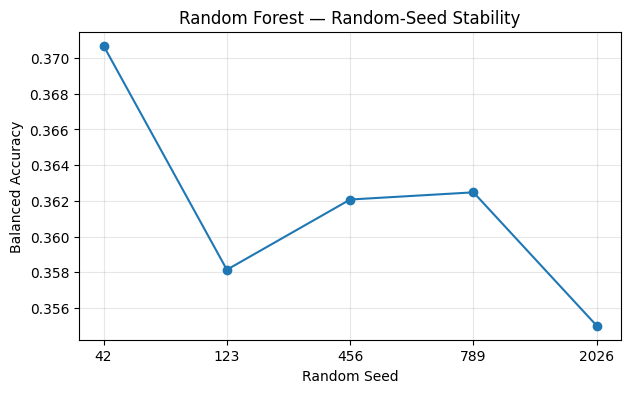

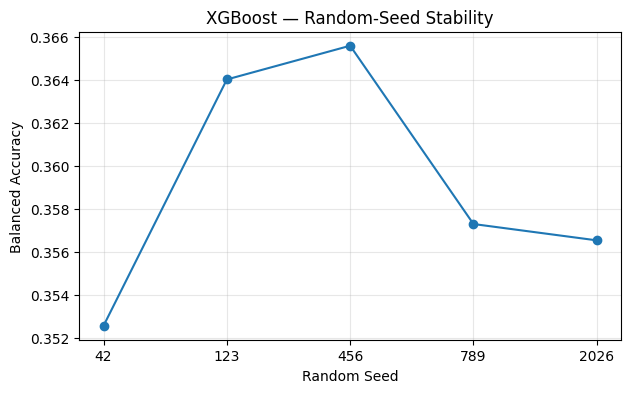

In [36]:
for model_name in seed_results_df["model"].unique():

    subset = seed_results_df[
        seed_results_df["model"] == model_name
    ]

    plt.figure(figsize=(7, 4))

    plt.plot(
        subset["seed"].astype(str),
        subset["balanced_accuracy"],
        marker="o"
    )

    plt.xlabel("Random Seed")
    plt.ylabel("Balanced Accuracy")
    plt.title(
        f"{model_name} — Random-Seed Stability"
    )

    plt.grid(alpha=0.3)
    plt.show()

## Target Threshold Sensitivity

The baseline target definition uses ±1.5% five-day forward return thresholds:

- Down: return < -1.5%
- Neutral: -1.5% ≤ return ≤ +1.5%
- Up: return > +1.5%

This experiment evaluates whether the main model conclusions remain stable
when alternative thresholds of ±1.0% and ±2.0% are used.

The temporal evaluation design remains unchanged:

- Train: 2020–2024
- Test: 2025

The same predictor features and baseline model configurations are retained.

**Step 36 — Define target function**

In [37]:
def create_threshold_target(forward_return, threshold):
    """
    Create 3-class target from 5-day forward return.

    0 = Down
    1 = Neutral
    2 = Up
    """

    if forward_return < -threshold:
        return 0

    elif forward_return > threshold:
        return 2

    else:
        return 1

In [38]:
print(create_threshold_target(-0.020, 0.015))  # Down -> 0
print(create_threshold_target( 0.005, 0.015))  # Neutral -> 1
print(create_threshold_target( 0.030, 0.015))  # Up -> 2

0
1
2


Step 37 — Define thresholds

In [39]:
THRESHOLDS = {
    "1.0%": 0.010,
    "1.5%": 0.015,
    "2.0%": 0.020
}

In [40]:
print("data_df" in globals())

True


Step 38 — First examine class distributions

In [41]:
threshold_class_results = []

for threshold_name, threshold_value in THRESHOLDS.items():

    temp_df = data_df.copy()

    temp_df["threshold_target"] = (
        temp_df["forward_return_5d"]
        .apply(
            lambda x: create_threshold_target(
                x,
                threshold_value
            )
        )
    )

    counts = (
        temp_df["threshold_target"]
        .value_counts()
        .sort_index()
    )

    proportions = (
        temp_df["threshold_target"]
        .value_counts(normalize=True)
        .sort_index()
    )

    for class_id, class_name in [
        (0, "Down"),
        (1, "Neutral"),
        (2, "Up")
    ]:

        threshold_class_results.append({
            "threshold": threshold_name,
            "class": class_name,
            "count": counts.get(class_id, 0),
            "proportion": proportions.get(class_id, 0)
        })


threshold_class_df = pd.DataFrame(
    threshold_class_results
)

display(threshold_class_df)

,threshold,class,count,proportion
0,1.0%,Down,2415,0.3277
1,1.0%,Neutral,1639,0.2224
2,1.0%,Up,3316,0.4499
3,1.5%,Down,2045,0.2775
4,1.5%,Neutral,2414,0.3275
5,1.5%,Up,2911,0.3950
6,2.0%,Down,1753,0.2379
7,2.0%,Neutral,3098,0.4204
8,2.0%,Up,2519,0.3418


Step 39 — Create a cleaner class-distribution table

In [42]:
class_distribution_pivot = (
    threshold_class_df
    .pivot(
        index="threshold",
        columns="class",
        values="proportion"
    )
)

display(class_distribution_pivot)
display(
    (
        class_distribution_pivot * 100
    ).round(2)
)

class,Down,Neutral,Up
threshold,,,
1.0%,0.3277,0.2224,0.4499
1.5%,0.2775,0.3275,0.3950
2.0%,0.2379,0.4204,0.3418


class,Down,Neutral,Up
threshold,,,
1.0%,32.7700,22.2400,44.9900
1.5%,27.7500,32.7500,39.5000
2.0%,23.7900,42.0400,34.1800


Step 40 — Build threshold experiment function

In [43]:
def run_threshold_experiment(
    data,
    threshold,
    feature_columns
):

    experiment_df = data.copy()

    # ------------------------------------------------------
    # Reconstruct target
    # ------------------------------------------------------

    experiment_df["threshold_target"] = (
        experiment_df["forward_return_5d"]
        .apply(
            lambda x: create_threshold_target(
                x,
                threshold
            )
        )
    )

    # ------------------------------------------------------
    # Temporal split
    # ------------------------------------------------------

    train = (
        experiment_df[
            experiment_df["date"].dt.year < TEST_YEAR
        ]
        .sort_values(["ticker", "date"])
        .copy()
    )

    test = (
        experiment_df[
            experiment_df["date"].dt.year == TEST_YEAR
        ]
        .sort_values(["ticker", "date"])
        .copy()
    )

    X_train_exp = train[feature_columns]
    y_train_exp = train["threshold_target"]

    X_test_exp = test[feature_columns]
    y_test_exp = test["threshold_target"]

    results = []

    # ------------------------------------------------------
    # Logistic Regression
    # ------------------------------------------------------

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(
        X_train_exp
    )

    X_test_scaled = scaler.transform(
        X_test_exp
    )

    lr = LogisticRegression(
        penalty="l2",
        class_weight="balanced",
        max_iter=2000,
        random_state=RANDOM_STATE
    )

    lr.fit(
        X_train_scaled,
        y_train_exp
    )

    lr_pred = lr.predict(
        X_test_scaled
    )

    lr_result = evaluate_classifier(
        y_test_exp,
        lr_pred
    )

    results.append({
        "model": "Logistic Regression",
        **lr_result
    })

    # ------------------------------------------------------
    # Random Forest
    # ------------------------------------------------------

    rf = RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    rf.fit(
        X_train_exp,
        y_train_exp
    )

    rf_pred = rf.predict(
        X_test_exp
    )

    rf_result = evaluate_classifier(
        y_test_exp,
        rf_pred
    )

    results.append({
        "model": "Random Forest",
        **rf_result
    })

    # ------------------------------------------------------
    # XGBoost
    # ------------------------------------------------------

    xgb = XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    xgb.fit(
        X_train_exp,
        y_train_exp
    )

    xgb_pred = xgb.predict(
        X_test_exp
    )

    xgb_result = evaluate_classifier(
        y_test_exp,
        xgb_pred
    )

    results.append({
        "model": "XGBoost",
        **xgb_result
    })

    return pd.DataFrame(results)

Step 41 — Run all three thresholds

In [44]:
all_threshold_results = []

for threshold_name, threshold_value in THRESHOLDS.items():

    print(
        f"Running threshold: ±{threshold_name}"
    )

    result = run_threshold_experiment(
        data=data_df,
        threshold=threshold_value,
        feature_columns=FEATURE_COLUMNS
    )

    result["threshold"] = threshold_name

    all_threshold_results.append(
        result
    )


threshold_results_df = pd.concat(
    all_threshold_results,
    ignore_index=True
)

display(threshold_results_df)

Running threshold: ±1.0%
Running threshold: ±1.5%
Running threshold: ±2.0%


,model,accuracy,balanced_accuracy,macro_f1,threshold
0,Logistic Regression,0.3584,0.3750,0.3599,1.0%
1,Random Forest,0.3611,0.3479,0.2910,1.0%
2,XGBoost,0.3655,0.3498,0.3163,1.0%
3,Logistic Regression,0.3885,0.3910,0.3821,1.5%
4,Random Forest,0.3531,0.3707,0.3543,1.5%
5,XGBoost,0.3372,0.3526,0.3379,1.5%
6,Logistic Regression,0.4044,0.4026,0.3857,2.0%
7,Random Forest,0.4018,0.3696,0.3688,2.0%
8,XGBoost,0.4204,0.4007,0.3994,2.0%


Step 42 — Show the important metrics only

In [45]:
threshold_summary = (
    threshold_results_df[
        [
            "threshold",
            "model",
            "balanced_accuracy",
            "macro_f1"
        ]
    ]
    .sort_values(
        ["threshold", "balanced_accuracy"],
        ascending=[True, False]
    )
)

display(threshold_summary)

,threshold,model,balanced_accuracy,macro_f1
0,1.0%,Logistic Regression,0.3750,0.3599
2,1.0%,XGBoost,0.3498,0.3163
1,1.0%,Random Forest,0.3479,0.2910
3,1.5%,Logistic Regression,0.3910,0.3821
4,1.5%,Random Forest,0.3707,0.3543
5,1.5%,XGBoost,0.3526,0.3379
6,2.0%,Logistic Regression,0.4026,0.3857
8,2.0%,XGBoost,0.4007,0.3994
7,2.0%,Random Forest,0.3696,0.3688


Step 43 — Balanced Accuracy pivot table

In [46]:
threshold_ba_pivot = (
    threshold_results_df
    .pivot(
        index="threshold",
        columns="model",
        values="balanced_accuracy"
    )
)

display(threshold_ba_pivot)

model,Logistic Regression,Random Forest,XGBoost
threshold,,,
1.0%,0.3750,0.3479,0.3498
1.5%,0.3910,0.3707,0.3526
2.0%,0.4026,0.3696,0.4007


Step 44 — Macro F1 pivot

In [47]:
threshold_f1_pivot = (
    threshold_results_df
    .pivot(
        index="threshold",
        columns="model",
        values="macro_f1"
    )
)

display(threshold_f1_pivot)

model,Logistic Regression,Random Forest,XGBoost
threshold,,,
1.0%,0.3599,0.2910,0.3163
1.5%,0.3821,0.3543,0.3379
2.0%,0.3857,0.3688,0.3994


Step 45 — Identify the best model at each threshold

In [48]:
best_by_threshold = (
    threshold_results_df
    .loc[
        threshold_results_df
        .groupby("threshold")[
            "balanced_accuracy"
        ]
        .idxmax()
    ]
    [
        [
            "threshold",
            "model",
            "balanced_accuracy",
            "macro_f1"
        ]
    ]
    .sort_values("threshold")
)

display(best_by_threshold)

,threshold,model,balanced_accuracy,macro_f1
0,1.0%,Logistic Regression,0.3750,0.3599
3,1.5%,Logistic Regression,0.3910,0.3821
6,2.0%,Logistic Regression,0.4026,0.3857


Step 46 — Plot threshold sensitivity

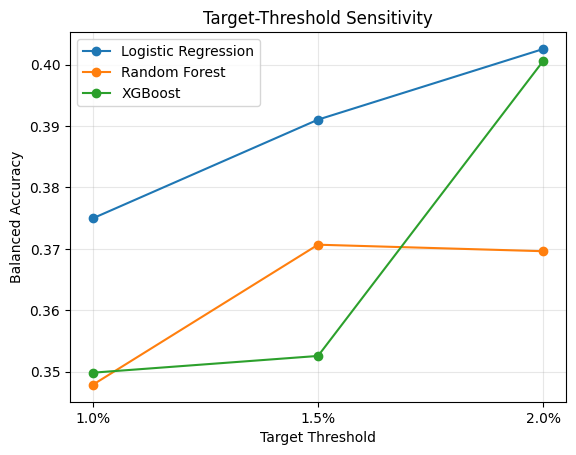

In [49]:
for model_name in threshold_results_df["model"].unique():

    subset = threshold_results_df[
        threshold_results_df["model"]
        == model_name
    ].copy()

    # Force correct threshold order
    order = ["1.0%", "1.5%", "2.0%"]

    subset["threshold"] = pd.Categorical(
        subset["threshold"],
        categories=order,
        ordered=True
    )

    subset = subset.sort_values(
        "threshold"
    )

    plt.plot(
        subset["threshold"],
        subset["balanced_accuracy"],
        marker="o",
        label=model_name
    )


plt.xlabel("Target Threshold")
plt.ylabel("Balanced Accuracy")
plt.title(
    "Target-Threshold Sensitivity"
)
plt.legend()
plt.grid(alpha=0.3)

plt.show()

Step 47 — Calculate change relative to ±1.5%

In [50]:
baseline_threshold_scores = (
    threshold_results_df[
        threshold_results_df["threshold"]
        == "1.5%"
    ]
    .set_index("model")[
        "balanced_accuracy"
    ]
)

threshold_change_df = (
    threshold_results_df.copy()
)

threshold_change_df[
    "baseline_balanced_accuracy"
] = threshold_change_df[
    "model"
].map(
    baseline_threshold_scores
)

threshold_change_df[
    "delta_balanced_accuracy"
] = (
    threshold_change_df[
        "balanced_accuracy"
    ]
    -
    threshold_change_df[
        "baseline_balanced_accuracy"
    ]
)

display(
    threshold_change_df[
        [
            "threshold",
            "model",
            "balanced_accuracy",
            "delta_balanced_accuracy",
            "macro_f1"
        ]
    ]
)

,threshold,model,balanced_accuracy,delta_balanced_accuracy,macro_f1
0,1.0%,Logistic Regression,0.3750,-0.0161,0.3599
1,1.0%,Random Forest,0.3479,-0.0228,0.2910
2,1.0%,XGBoost,0.3498,-0.0027,0.3163
3,1.5%,Logistic Regression,0.3910,0.0000,0.3821
4,1.5%,Random Forest,0.3707,0.0000,0.3543
5,1.5%,XGBoost,0.3526,0.0000,0.3379
6,2.0%,Logistic Regression,0.4026,0.0115,0.3857
7,2.0%,Random Forest,0.3696,-0.0011,0.3688
8,2.0%,XGBoost,0.4007,0.0481,0.3994


### Interpretation of Target-Threshold Sensitivity

The target-threshold sensitivity experiment evaluated three definitions of
five-day stock movement: ±1.0%, ±1.5%, and ±2.0%.

Logistic Regression achieved the highest Balanced Accuracy at all three
thresholds:

- ±1.0%: 0.3750
- ±1.5%: 0.3910
- ±2.0%: 0.4026

This indicates that the main model ranking is robust to reasonable changes in
the target definition.

Random Forest showed relatively moderate variation across thresholds, while
XGBoost was more sensitive. In particular, XGBoost Balanced Accuracy increased
from 0.3526 at the baseline ±1.5% threshold to 0.4007 at ±2.0%.

The stronger XGBoost performance at the wider threshold suggests that boosted
tree models may benefit when the classification task focuses on larger stock
movements and the Neutral region is expanded.

Overall, the principal conclusion remains stable: Logistic Regression is the
strongest pooled classical model across the tested threshold definitions.
However, model performance—especially for XGBoost—is sensitive to how stock
movement classes are operationally defined.

Step 49 — Create SMA_5 and EMA_5

## Window / Feature-Horizon Sensitivity

The baseline feature set contains medium- and long-horizon technical indicators,
including SMA_50, SMA_200, EMA_50, and EMA_200.

This robustness experiment evaluates whether adding short-term technical
indicators changes the main model conclusions.

The following configurations are compared:

1. Baseline feature set
2. Baseline + SMA_5 + EMA_5

All other experimental settings remain unchanged:

- Training period: 2020–2024
- Test period: 2025
- Target threshold: ±1.5%
- Same baseline model hyperparameters
- Same leakage controls

In [51]:
window_df = data_df.copy()

window_df = (
    window_df
    .sort_values(["ticker", "date"])
    .copy()
)

window_df["SMA_5"] = (
    window_df
    .groupby("ticker")["Close"]
    .transform(lambda x: x.rolling(5).mean())
)

window_df["EMA_5"] = (
    window_df
    .groupby("ticker")["Close"]
    .transform(lambda x: x.ewm(span=5, adjust=False).mean())
)

SStep 50 — Remove new NaN rows

In [52]:
window_df = window_df.dropna(
    subset=["SMA_5", "EMA_5"]
).copy()

print(window_df[["SMA_5", "EMA_5"]].isna().sum())

SMA_5    0
EMA_5    0
dtype: int64


Step 51 — Define two feature sets

In [53]:
baseline_features = FEATURE_COLUMNS.copy()

extended_features = (
    FEATURE_COLUMNS
    + ["SMA_5", "EMA_5"]
)

Step 52 — Simple evaluation function

In [54]:
def run_feature_experiment(data, features):

    train = data[
        data["date"].dt.year < TEST_YEAR
    ].copy()

    test = data[
        data["date"].dt.year == TEST_YEAR
    ].copy()

    X_train_exp = train[features]
    y_train_exp = train[TARGET]

    X_test_exp = test[features]
    y_test_exp = test[TARGET]

    results = []

    # Logistic Regression
    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train_exp)
    X_test_scaled = scaler.transform(X_test_exp)

    lr = LogisticRegression(
        penalty="l2",
        class_weight="balanced",
        max_iter=2000,
        random_state=RANDOM_STATE
    )

    lr.fit(X_train_scaled, y_train_exp)

    pred = lr.predict(X_test_scaled)

    results.append({
        "model": "Logistic Regression",
        "balanced_accuracy": balanced_accuracy_score(
            y_test_exp, pred
        ),
        "macro_f1": f1_score(
            y_test_exp,
            pred,
            average="macro"
        )
    })

    # Random Forest
    rf = RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    rf.fit(X_train_exp, y_train_exp)

    pred = rf.predict(X_test_exp)

    results.append({
        "model": "Random Forest",
        "balanced_accuracy": balanced_accuracy_score(
            y_test_exp, pred
        ),
        "macro_f1": f1_score(
            y_test_exp,
            pred,
            average="macro"
        )
    })

    # XGBoost
    xgb = XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    xgb.fit(X_train_exp, y_train_exp)

    pred = xgb.predict(X_test_exp)

    results.append({
        "model": "XGBoost",
        "balanced_accuracy": balanced_accuracy_score(
            y_test_exp, pred
        ),
        "macro_f1": f1_score(
            y_test_exp,
            pred,
            average="macro"
        )
    })

    return pd.DataFrame(results)

Step 53 — Run baseline vs extended

In [55]:
baseline_window_results = run_feature_experiment(
    window_df,
    baseline_features
)

baseline_window_results["feature_set"] = "Baseline"


extended_window_results = run_feature_experiment(
    window_df,
    extended_features
)

extended_window_results["feature_set"] = "Baseline + SMA_5 + EMA_5"

In [56]:
window_results_df = pd.concat(
    [
        baseline_window_results,
        extended_window_results
    ],
    ignore_index=True
)

display(window_results_df)

,model,balanced_accuracy,macro_f1,feature_set
0,Logistic Regression,0.3942,0.3805,Baseline
1,Random Forest,0.3448,0.3138,Baseline
2,XGBoost,0.3624,0.3494,Baseline
3,Logistic Regression,0.3915,0.3773,Baseline + SMA_5 + EMA_5
4,Random Forest,0.3467,0.3109,Baseline + SMA_5 + EMA_5
5,XGBoost,0.3581,0.3443,Baseline + SMA_5 + EMA_5


Step 54 — Easy comparison table

In [57]:
window_ba_pivot = window_results_df.pivot(
    index="model",
    columns="feature_set",
    values="balanced_accuracy"
)

display(window_ba_pivot)

feature_set,Baseline,Baseline + SMA_5 + EMA_5
model,,
Logistic Regression,0.3942,0.3915
Random Forest,0.3448,0.3467
XGBoost,0.3624,0.3581


### Interpretation of Window Sensitivity

The baseline feature set was compared with an extended feature set including
SMA_5 and EMA_5.

The changes in Balanced Accuracy were small for all three models:

- Logistic Regression: -0.0027
- Random Forest: +0.0019
- XGBoost: -0.0043

The model ranking also remained unchanged.

This suggests that the main conclusions are robust to the addition of
short-term 5-day technical indicators and are not strongly dependent on this
feature-window specification.